# Representational similarity analysis among multiple neural manifolds


In addition to measuring the similairity between two neural manifolds, CaTrace also provides convenient APIs to compute the pairwise similarity between multiple neural manifolds.
We will download an example dataset from a zebrafish olfactory brain region and demonstrate how to compute the pairwise similarities.

In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
# Download example dataset

import kagglehub

# Download latest version
demo_data_dir = kagglehub.dataset_download("hubosynapse/catrace-demo")

print("Dataset downloaded to:", demo_data_dir)

Dataset downloaded to: /home_fmi/01/hubo/.cache/kagglehub/datasets/hubosynapse/catrace-demo/versions/1


In [50]:
import os
from catrace.dataio import load_tracedf_from_hdf5
dff = load_tracedf_from_hdf5(os.path.join(demo_data_dir, "example_manifolds_zebrafish_pDp.h5"))
dff

neuron_id             0         3         6         9         12        15    \
odor trial frame                                                               
Phe  0     0      0.087327  0.000000  0.364393  3.401696  0.198831  0.222916   
           1      0.124883  0.000000  0.389797  2.382160  0.183961  0.281749   
           2      0.193008  0.000000  0.261387  1.833974  0.188226  0.294678   
           3      0.156106  0.101239  0.328432  1.030327  0.311956  0.427573   
           4      0.178299  0.061524  0.251610  0.782781  0.300017  0.427398   
...                    ...       ...       ...       ...       ...       ...   
GCA  2     156    0.397823  0.032051  0.197996  1.149775  0.342550  0.133098   
           157    0.395247  0.000000  0.147733  1.927241  0.343461  0.104777   
           158    0.406598  0.033626  0.150963  1.658847  0.465890  0.037147   
           159    0.548564  0.117669  0.038714  1.228765  0.437184  0.000000   
           160    0.363364  0.114395  0.197050  0.698210  0.438365  0.037931   

neuron_id             18        21        24        27    ...      1320  \
odor trial frame                                          ...             
Phe  0     0      0.156371  0.111882  0.062771  0.211053  ...  0.000000   
           1      0.113549  0.177746  0.072316  0.187708  ...  0.000000   
           2      0.114015  0.401941  0.110502  0.210519  ...  0.000000   
           3      0.071192  0.480165  0.069942  0.143565  ...  0.000000   
           4      0.166722  0.302050  0.033885  0.152268  ...  0.000000   
...                    ...       ...       ...       ...  ...       ...   
GCA  2     156    0.073760  0.019886  0.453068  0.000000  ...  0.203370   
           157    0.073063  0.038100  0.600632  0.000000  ...  0.222437   
           158    0.080100  0.033084  0.484723  0.000000  ...  0.231907   
           159    0.115039  0.000000  0.397446  0.000000  ...  0.099963   
           160    0.217217  0.000000  0.260369  0.000000  ...  0.007203   

neuron_id             1323      1326      1329      1332      1335      1338  \
odor trial frame                                                               
Phe  0     0      0.000000  0.096166  0.081480  0.061187  0.162319  0.229935   
           1      0.024929  0.075745  0.039305  0.097043  0.123529  0.341941   
           2      0.026147  0.010184  0.081434  0.094906  0.146486  0.574860   
           3      0.046711  0.084686  0.046592  0.071153  0.066409  1.140675   
           4      0.053644  0.107827  0.052891  0.069509  0.082030  1.076845   
...                    ...       ...       ...       ...       ...       ...   
GCA  2     156    0.584936  0.216866  0.611091  0.166145  1.826299  0.297510   
           157    0.344783  0.150408  0.540862  0.216696  2.579315  0.296145   
           158    0.208518  0.251466  0.460306  0.217961  2.323958  0.262159   
           159    0.142863  0.178874  0.377149  0.158550  2.331792  0.339583   
           160    0.118876  0.212228  0.411285  0.183784  1.892450  0.458288   

neuron_id             1341      1344      1347  
odor trial frame                                
Phe  0     0      0.111886  0.186035  0.109348  
           1      0.114628  0.459607  0.123736  
           2      0.016349  0.357506  0.086978  
           3      0.043885  0.251076  0.040477  
           4      0.000000  0.180134  0.058504  
...                    ...       ...       ...  
GCA  2     156    0.090758  0.000000  1.886180  
           157    0.012790  0.000000  1.413937  
           158    0.025896  0.000000  1.200838  
           159    0.000000  0.000000  1.283291  
           160    0.033679  0.000000  1.174082  

[2898 rows x 450 columns]

In [51]:
# Select a subset of odors for simplicity
odors_to_keep = ['Phe', 'Arg', 'TCA']
from catrace.process_time_trace import select_odors_df
dff = select_odors_df(dff, odors_to_keep)

/tungstenfs/scratch/gfriedri/hubo/Software/python_env/catrace_cpu/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tungstenfs/scratch/gfriedri/hubo/Ca_imaging/scripts/catrace/catrace/dimensionality_reduction.py:385: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = embeddf.groupby(level=manifold_level)


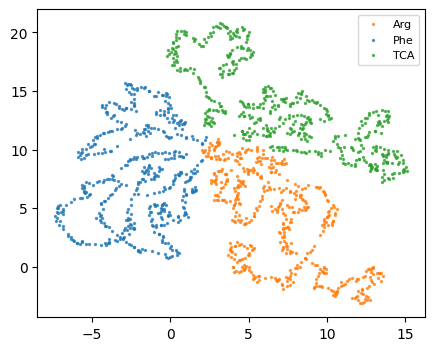

In [52]:
# Visualize the manifolds with UMAP embedding
import matplotlib.pyplot as plt
from catrace.dimensionality_reduction import compute_umap, plot_embed_2d

umap_params = {
    'n_components': 2,
    'n_neighbors': 15,
    'min_dist': 0.8,
    'metric': 'euclidean',
    'random_state': 42,
}
embeddf = compute_umap(dff, umap_params)

fig, ax = plt.subplots(figsize=(5, 4))
component_idx = [0, 1]
plot_embed_2d(embeddf, component_idx, ax=ax, manifold_level='odor')
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='upper right', fontsize=8)


In [53]:
# Compute pattern correlation, cosine distance between each pair of trials
from catrace.similarity import compute_similarity_mat, pattern_correlation, cosine_distance
frame_rate = 7.5
pattern_correlation_mat = compute_similarity_mat(dff, time_window=(38, 63), similarity_func=pattern_correlation, xname='frame', frame_rate=None)
print("Pattern Correlation Matrix:")
cosine_distance_mat = compute_similarity_mat(dff, time_window=(38, 63), similarity_func=cosine_distance, xname='frame', frame_rate=None)
print(cosine_distance_mat)


Pattern Correlation Matrix:
odor             Phe                           Arg                      \
trial              0         1         2         0         1         2   
odor trial                                                               
Phe  0      0.000000  0.213671  0.311946  0.398575  0.376093  0.472632   
     1      0.213671  0.000000  0.256425  0.451538  0.429266  0.488851   
     2      0.311946  0.256425  0.000000  0.523449  0.498022  0.454734   
Arg  0      0.398575  0.451538  0.523449  0.000000  0.145519  0.245797   
     1      0.376093  0.429266  0.498022  0.145519  0.000000  0.238535   
     2      0.472632  0.488851  0.454734  0.245797  0.238535  0.000000   
TCA  0      0.536509  0.538411  0.557193  0.411551  0.426212  0.452222   
     1      0.547579  0.499744  0.517084  0.417101  0.424110  0.401849   
     2      0.556341  0.553172  0.537157  0.472747  0.454754  0.434701   

odor             TCA                      
trial              0         1         2

odor             Phe                           Arg                      \
trial              0         1         2         0         1         2   
odor trial                                                               
Phe  0      1.000000  0.648811  0.513331  0.293567  0.333312  0.217037   
     1      0.648811  1.000000  0.601509  0.202212  0.241346  0.193060   
     2      0.513331  0.601509  1.000000  0.128101  0.170882  0.286523   
Arg  0      0.293567  0.202212  0.128101  1.000000  0.716380  0.564580   
     1      0.333312  0.241346  0.170882  0.716380  1.000000  0.577366   
     2      0.217037  0.193060  0.286523  0.564580  0.577366  1.000000   
TCA  0      0.168615  0.168071  0.173386  0.327708  0.302447  0.297550   
     1      0.139303  0.217093  0.223571  0.305383  0.292892  0.366876   
     2      0.116090  0.123910  0.186015  0.199262  0.229804  0.307128   

odor             TCA                      
trial              0         1         2  
odor trial               

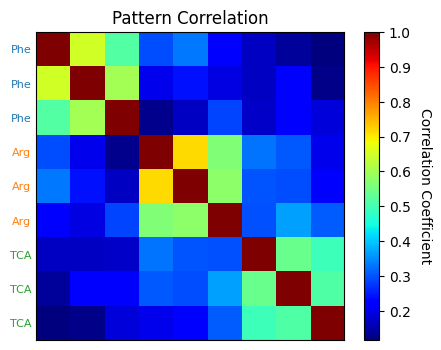

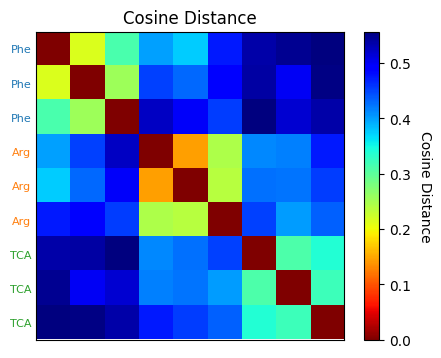

In [56]:
# Plot the similarity matrices
import matplotlib.pyplot as plt
from catrace.similarity import plot_similarity_mat

fig, ax = plt.subplots(figsize=(5, 4))
im = plot_similarity_mat(pattern_correlation_mat, ax=ax, cmap='jet', title='Pattern Correlation', manifold_level='odor')
# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=15)

fig, ax = plt.subplots(figsize=(5, 4))
im = plot_similarity_mat(cosine_distance_mat, ax=ax, cmap='jet_r', title='Cosine Distance', manifold_level='odor')
# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Cosine Distance', rotation=270, labelpad=15)
                         

In [63]:
# Compute Euclidean distance and Mahalanobis distance between each pair of manifolds (odors)
from catrace.similarity import sample_neuron_and_comopute_distance_mat
euclidean_distance_mat = sample_neuron_and_comopute_distance_mat(
    dff,
    sample_size=100,
    seed=42,
    metric='center_euclidean',
    manifold_level='odor',
    time_window=(38, 63),
    shuffle_config=None,
    time_name='frame',
)
print("Euclidean Distance Matrix:")
print(euclidean_distance_mat)

mahalanobis_distance_mat = sample_neuron_and_comopute_distance_mat(
    dff,
    sample_size=100,
    seed=42,
    metric='mahal',
    reg=1e-5,
    manifold_level='odor',
    time_window=(38, 63),
    shuffle_config=None,
    time_name='frame',
)
print("Mahalanobis Distance Matrix:")
print(mahalanobis_distance_mat)

Euclidean Distance Matrix:
ref_manifold           Phe        Arg        TCA
sample_manifold                                 
Phe               0.000000  15.958096  11.897152
Arg              15.958096   0.000000  15.718687
TCA              11.897152  15.718687   0.000000
Mahalanobis Distance Matrix:
ref_manifold             Phe          Arg          TCA
sample_manifold                                       
Phe                 8.693328  1861.447077  1932.242483
Arg              2102.717292     8.698460  2374.178314
TCA              1343.848711   989.991795     8.681098


ylabel_ vfontsize: 8
ylabel_ vfontsize: 8


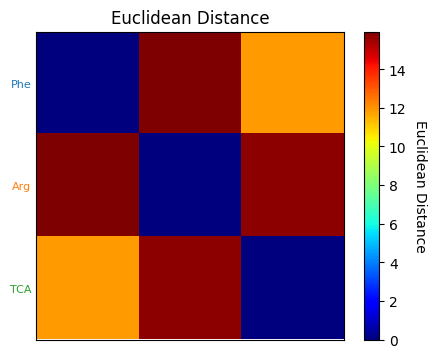

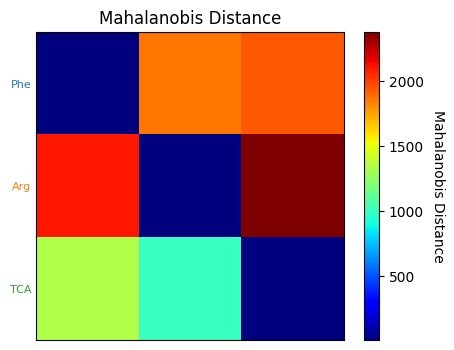

In [65]:
# Plot the Euclidean and Mahalanobis distance matrices
import matplotlib.pyplot as plt
from catrace.similarity import plot_similarity_mat
fig, ax = plt.subplots(figsize=(5, 4))
im = plot_similarity_mat(euclidean_distance_mat, ax=ax, cmap='jet', title='Euclidean Distance', manifold_level='sample_manifold')
# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Euclidean Distance', rotation=270, labelpad=15)

fig, ax = plt.subplots(figsize=(5, 4))
im = plot_similarity_mat(mahalanobis_distance_mat, ax=ax, cmap='jet', title='Mahalanobis Distance', manifold_level='sample_manifold')
# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mahalanobis Distance', rotation=270, labelpad=15)
                         